In [7]:
from ase.io import read, iread
import os
from ase.formula import Formula
from ase.io.trajectory import Trajectory
energy_H = -12.3367290792984
energy_10_10_slab = -457017.7855818
# traj = iread('all_data.xyz')
# for atoms in traj:
#     h = Formula(atoms.get_chemical_formula()).count()['H']
#     #number_of_H.append(h)
#     if 'supercell' in file:
#         ads_energy = (atoms.get_potential_energy() - (12*energy_10_10_slab)-(h*energy_H))/h
#     else:
#         ads_energy = (atoms.get_potential_energy() - (4*energy_10_10_slab)-(h*energy_H))/h
#     print(ads_energy)
traj_out = Trajectory('all_images.traj', 'a')
i = 0
for file in os.listdir():
    if file.endswith('.traj') and file!='all_images.traj':
        # print(file)
        # print('\n')
        traj = iread(file)
        for atoms in traj:
            h = Formula(atoms.get_chemical_formula()).count()['H']
            #number_of_H.append(h)
            if 'supercell' in file:
                ads_energy = (atoms.get_potential_energy() - (12*energy_10_10_slab)-(h*energy_H))/h
            else:
                ads_energy = (atoms.get_potential_energy() - (4*energy_10_10_slab)-(h*energy_H))/h
            # print(ads_energy)
            atoms.info['E_ads_per_H'] = ads_energy
            traj_out.write(atoms)
            i+=1
traj_out.close()
print(f'total images = {i}')

total images = 545


In [16]:
from dscribe.descriptors import SOAP
import numpy as np

In [9]:
test_atoms = read('H_slab_Co_10-10_high_coverage_bridge_1.traj')

In [25]:
h_indices = []
co_indices = []
for atom in test_atoms:
    if atom.symbol=='H':
        # print(atom.index)
        h_indices.append(atom.index)
    else:
        co_indices.append(atom.index)
species = ['Co', 'H'] # Example
soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=6, l_max=4, average='off')
d = soap.create(test_atoms)
print(np.mean(d[h_indices], axis=0).shape)
print(np.mean(d[co_indices],axis=0).shape)
print(np.hstack([np.mean(d[h_indices], axis=0),np.mean(d[co_indices],axis=0)]).shape)

(390,)
(390,)
(780,)


In [28]:
traj = iread('all_data.xyz')
descs = []
e_ads_per_h = []
for atoms in traj:
    co_indices = []
    h_indices = []
    for atom in test_atoms:
        if atom.symbol=='H':
            # print(atom.index)
            h_indices.append(atom.index)
        else:
            co_indices.append(atom.index)
    species = ['Co', 'H'] # Example
    soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=6, l_max=4, average='off')
    d = soap.create(test_atoms)
    d_modified = np.hstack([np.mean(d[h_indices], axis=0),np.mean(d[co_indices],axis=0)])
    descs.append(d_modified)
    e_ads = atoms.info['E_ads_per_H']
    e_ads_per_h.append(e_ads)
descs = np.vstack(descs)

e_ads_per_h = np.array(e_ads_per_h)
print(descs.shape)
print(e_ads_per_h.shape)

(545, 780)
(545,)


In [29]:
np.savez("SOAP_data_with_H_ads_energy.npz",descs=descs,e_ads_per_h=e_ads_per_h)

In [ ]:
data = np.load('SOAP_data_with_H_ads_energy.npz')
descs = 

In [1]:
import torch
from torch_geometric.data import Data
from torch_geometric.nn.pool import knn_graph
import random

In [3]:
pos = torch.randn(num_nodes, 2)
print(pos)

tensor([[-0.2451,  0.3019],
        [-0.9627, -0.9223],
        [-0.5598, -0.6906],
        [ 0.6714,  0.8701],
        [-0.9068, -1.4321]])


In [4]:
edge_index = knn_graph(pos, k=4, loop=False)

In [5]:
y = x.sum(dim=1).mean().unsqueeze(0)

data = Data(x=x, edge_index=edge_index, pos=pos, y=y)

In [6]:
print(data.pos)

tensor([[-0.2451,  0.3019],
        [-0.9627, -0.9223],
        [-0.5598, -0.6906],
        [ 0.6714,  0.8701],
        [-0.9068, -1.4321]])


### visualizing geometric data object as a networkx graph

In [7]:
import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt

In [8]:
G = to_networkx(data,to_undirected=True,node_attrs=['x'],edge_attrs=None)

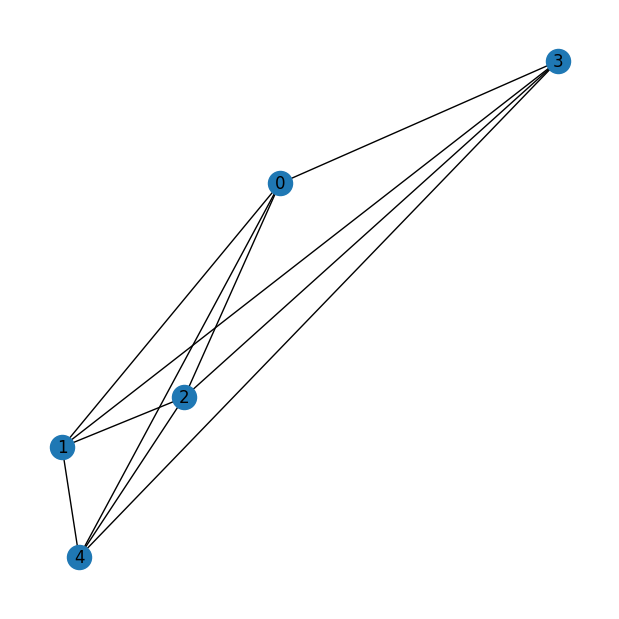

In [9]:
# the position helps to visualize the true graph. If pos is not passed to nx.draw, we lose information on 
# the position of the nodes (see the cell below this)
pos = {i: data.pos[i].tolist() for i in range(data.num_nodes)}

plt.figure(figsize=(6, 6))
nx.draw(G,pos,node_size=300,with_labels=True)
plt.show()

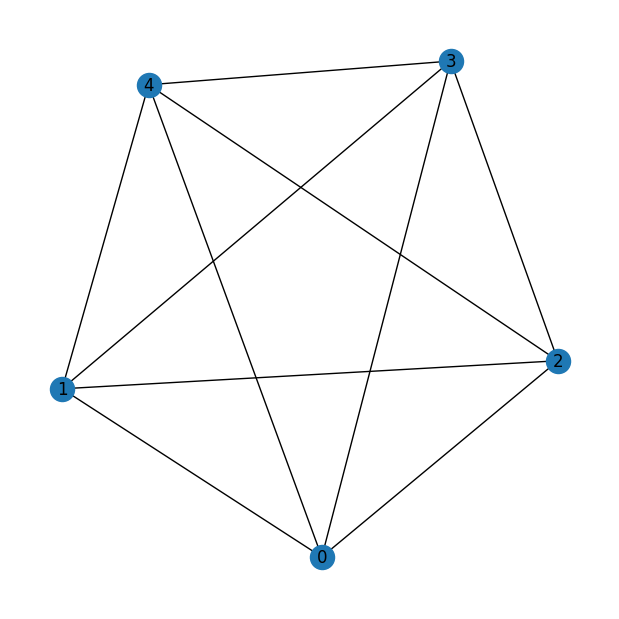

In [10]:
# this will give a neat graph 
plt.figure(figsize=(6, 6))
nx.draw(G,node_size=300,with_labels=True)
plt.show()

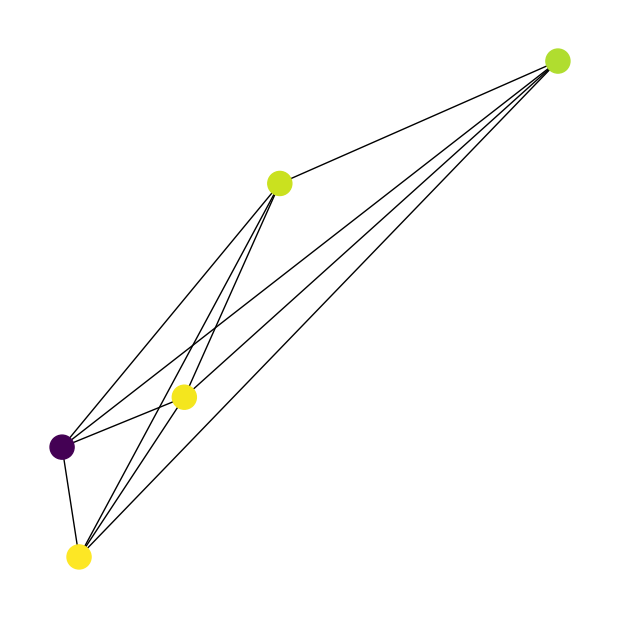

In [11]:
node_colors = data.x[:, 0].numpy()

plt.figure(figsize=(6, 6))
nx.draw(G,pos,node_color=node_colors,node_size=300,with_labels=False)
# plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'))
plt.show()


In [12]:
def create_random_graph(min_nodes=5, max_nodes=30, num_node_features=10, k=4):
    num_nodes = random.randint(min_nodes, max_nodes)

    x = torch.randn(num_nodes, num_node_features)

    pos = torch.randn(num_nodes, 2)

    edge_index = knn_graph(pos, k=k, loop=False)

    y = x.sum(dim=1).mean().unsqueeze(0)

    return Data(
        x=x,
        edge_index=edge_index,
        pos=pos,
        y=y
    )

In [13]:
def create_dataset(num_graphs=1000):
    dataset = []
    for _ in range(num_graphs):
        graph = create_random_graph()
        dataset.append(graph)
    return dataset

In [118]:
dataset = create_dataset(300)

In [119]:
print()
# print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset[0].x.shape[1]}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Number of graphs: 300
Number of features: 10

Data(x=[19, 10], edge_index=[2, 76], y=[1], pos=[19, 2])
Number of nodes: 19
Number of edges: 76
Average node degree: 4.00
Has isolated nodes: False
Has self-loops: False
Is undirected: False


In [120]:
def plot_geometric_data_as_graph(data):
    G = to_networkx(data, to_undirected=True, node_attrs=['x'], edge_attrs=None)
    pos = {i: data.pos[i].tolist() for i in range(data.num_nodes)}
    fig = plt.figure(figsize=(6, 6))
    nx.draw(G,pos,node_size=300,with_labels=False)
    plt.show()
    fig.clear()

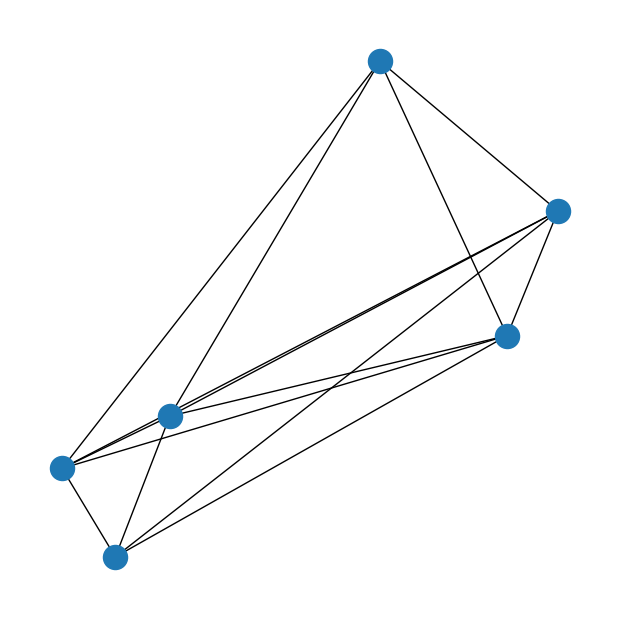

In [121]:
plot_geometric_data_as_graph(dataset[10])

### Splitting the dataset in to train and test dataset

In [122]:
train_dataset = dataset[:200]
val_dataset = dataset[200:260]
test_dataset = dataset[260:]

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of validation graphs: {len(val_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

Number of training graphs: 200
Number of validation graphs: 60
Number of test graphs: 40


In [123]:
print("Train y mean:", torch.cat([d.y for d in train_dataset]).mean())
print("Val y mean:", torch.cat([d.y for d in val_dataset]).mean())

Train y mean: tensor(-0.0363)
Val y mean: tensor(0.1240)


In [124]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

for step, data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('=======')
    print(f'Number of graphs in the current batch: {data.num_graphs}')
    print(data)
    print()

Step 1:
Number of graphs in the current batch: 64
DataBatch(x=[1119, 10], edge_index=[2, 4476], y=[64], pos=[1119, 2], batch=[1119], ptr=[65])

Step 2:
Number of graphs in the current batch: 64
DataBatch(x=[1066, 10], edge_index=[2, 4264], y=[64], pos=[1066, 2], batch=[1066], ptr=[65])

Step 3:
Number of graphs in the current batch: 64
DataBatch(x=[1108, 10], edge_index=[2, 4432], y=[64], pos=[1108, 2], batch=[1108], ptr=[65])

Step 4:
Number of graphs in the current batch: 8
DataBatch(x=[141, 10], edge_index=[2, 564], y=[8], pos=[141, 2], batch=[141], ptr=[9])



In [125]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class GCNRegressor(torch.nn.Module):
    def __init__(self, num_node_features,hidden_channels):
        super(GCNRegressor, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.lin(x)
        
        return x

In [131]:
model = GCNRegressor(num_node_features=10,hidden_channels=128)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

In [132]:
def train():
    model.train()
    mse_total = 0
    loss_total = 0
    for data in train_loader:  # Iterate in batches over the training dataset.
        out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
        loss = criterion(out.squeeze(), data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.
        optimizer.zero_grad() # Clear gradients.
        mse_value = F.mse_loss(out.squeeze(), data.y).detach().item()
        mse_total+=mse_value
        loss_total+=loss.item()
#         print(f'{out=}')
#         print(f'{data.y}')
#     print(mse_total)
    return mse_total / len(train_loader), out, loss_total/len(train_loader)

def test(loader):
    model.eval()
    mse_total = 0
    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            out = model(data.x, data.edge_index, data.batch)  
            pred = out  # Use the class with highest probability.
            mse_value = F.mse_loss(out.squeeze(), data.y).detach().item()
            mse_total+=mse_value
    #         print(pred)
    #         correct += int((pred == data.y).sum())  # Check against ground-truth labels.
    return mse_total / len(loader)  # Derive ratio of correct predictions.

In [133]:
train_mse = []
val_mse = []
loss = []
for epoch in range(1, 100):
    train_mse_epoch, out, loss_epoch = train()
    train_mse.append(train_mse_epoch)
    loss.append(loss_epoch)
    
#     train_mse = test(train_loader)
    val_mse_epoch = test(val_loader)
    val_mse.append(val_mse_epoch)
    print(f'Epoch: {epoch:03d}, Loss: {loss_epoch:.4f}, Train MSE: {train_mse_epoch:.4f}, Validation MSE: {val_mse_epoch:.4f}')
#     print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Loss: 0.7349, Train MSE: 0.7349, Validation MSE: 0.6693
Epoch: 002, Loss: 0.6586, Train MSE: 0.6586, Validation MSE: 0.6092
Epoch: 003, Loss: 0.6482, Train MSE: 0.6482, Validation MSE: 0.5303
Epoch: 004, Loss: 0.5435, Train MSE: 0.5435, Validation MSE: 0.4519
Epoch: 005, Loss: 0.4265, Train MSE: 0.4265, Validation MSE: 0.3358
Epoch: 006, Loss: 0.2933, Train MSE: 0.2933, Validation MSE: 0.2193
Epoch: 007, Loss: 0.1895, Train MSE: 0.1895, Validation MSE: 0.1691
Epoch: 008, Loss: 0.1425, Train MSE: 0.1425, Validation MSE: 0.1886
Epoch: 009, Loss: 0.1452, Train MSE: 0.1452, Validation MSE: 0.2176
Epoch: 010, Loss: 0.1858, Train MSE: 0.1858, Validation MSE: 0.2152
Epoch: 011, Loss: 0.1427, Train MSE: 0.1427, Validation MSE: 0.1990
Epoch: 012, Loss: 0.1558, Train MSE: 0.1558, Validation MSE: 0.1946
Epoch: 013, Loss: 0.1506, Train MSE: 0.1506, Validation MSE: 0.1871
Epoch: 014, Loss: 0.1212, Train MSE: 0.1212, Validation MSE: 0.1806
Epoch: 015, Loss: 0.1324, Train MSE: 0.1324, Val

In [134]:
print(loss)

[0.7349091172218323, 0.658630296587944, 0.6482208147644997, 0.5435082614421844, 0.42652713507413864, 0.2932988926768303, 0.18951831758022308, 0.14247355982661247, 0.14515913650393486, 0.18584123626351357, 0.14272712543606758, 0.15575169399380684, 0.15063151717185974, 0.12119164504110813, 0.1323856394737959, 0.1083273347467184, 0.14583388715982437, 0.11317535117268562, 0.12506932765245438, 0.10787701606750488, 0.12103079445660114, 0.10175198689103127, 0.11331728473305702, 0.09309705253690481, 0.10230758599936962, 0.08425669185817242, 0.11477694101631641, 0.08661349676549435, 0.08171350136399269, 0.08635326474905014, 0.07825717516243458, 0.0967184491455555, 0.0907080639153719, 0.08655401412397623, 0.07900030445307493, 0.07533282227814198, 0.08328169770538807, 0.06091671483591199, 0.07984710857272148, 0.06445645820349455, 0.08596359100192785, 0.06921875942498446, 0.07241741009056568, 0.08527937531471252, 0.058858354575932026, 0.06860151514410973, 0.0734387906268239, 0.06818031053990126, 0

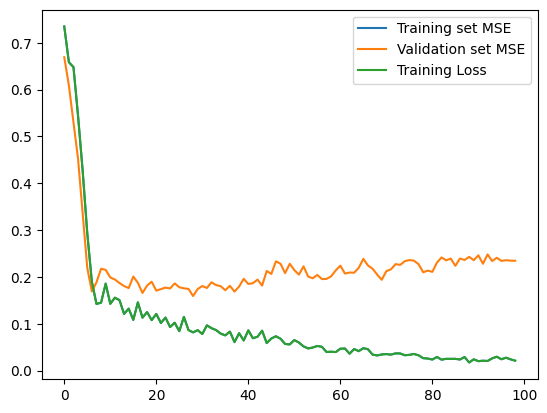

In [135]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(range(len(train_mse)), train_mse, label='Training set MSE')
plt.plot(range(len(val_mse)), val_mse, label='Validation set MSE')
plt.plot(range(len(loss)), loss, label='Training Loss')
plt.legend()
plt.show()